In [1]:
# ==============================================================
# Libraries
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import treecorr
import os

In [2]:
# ==============================================================
# Utility Functions
# ==============================================================

def load_frb_catalog(filepath):
    """
    Load FRB catalog and apply basic validation cuts.
    """
    df = pd.read_csv(filepath)
    df = df[["RA", "DEC"]].dropna()
    valid = (df["RA"] >= 0) & (df["RA"] < 360) & (df["DEC"] >= -90) & (df["DEC"] <= 90)
    return df[valid].reset_index(drop=True)


def generate_random_from_data(df, n_random, seed=None):
    """
    Generate random catalog by resampling the angular footprint
    of the data (RA uniform, DEC drawn from data distribution).
    
    This preserves the survey geometry approximately.
    """
    rng = np.random.default_rng(seed)
    
    # RA uniform (safe)
    ra = 360.0 * rng.random(n_random)
    
    # DEC resampled from data (preserves footprint)
    dec = rng.choice(df["DEC"].values, size=n_random, replace=True)
    
    return pd.DataFrame({"RA": ra, "DEC": dec})


def get_2pacf(df_data, df_rand, min_sep=1.0, max_sep=180.0, nbins=15):
    """
    Compute angular two-point correlation function using TreeCorr.
    """
    cat = treecorr.Catalog(ra=df_data["RA"], dec=df_data["DEC"],
                           ra_units="deg", dec_units="deg")
    rnd = treecorr.Catalog(ra=df_rand["RA"], dec=df_rand["DEC"],
                           ra_units="deg", dec_units="deg")

    config = dict(min_sep=min_sep, max_sep=max_sep,
                  nbins=nbins, sep_units="deg", bin_slop=0.0)

    nn = treecorr.NNCorrelation(**config)
    rr = treecorr.NNCorrelation(**config)
    dr = treecorr.NNCorrelation(**config)

    nn.process(cat)
    rr.process(rnd)
    dr.process(cat, rnd)

    nn.calculateXi(rr=rr, dr=dr)

    return nn.rnom, nn.xi


def get_abs_sum_test(theta, w, coarse_bins):
    """
    Compute Absolute Sum Test over coarse angular bins.
    """
    abs_vals = []
    for i in range(len(coarse_bins) - 1):
        mask = (theta >= coarse_bins[i]) & (theta < coarse_bins[i + 1])
        abs_vals.append(np.abs(np.mean(w[mask])) if np.any(mask) else 0.0)
    return np.array(abs_vals)

In [3]:
# ==============================================================
# Configuration
# ==============================================================

BASE_PATH = "/home/brunowesley/projetos/FRB-isotropy-tests/FRB_catalogs/"
NORTH_PATHS = [os.path.join(BASE_PATH, f"SkyPosition_North{i}.csv") for i in range(1, 16)]
SOUTH_PATH = os.path.join(BASE_PATH, "SkyPosition_South.csv")

COARSE_BINS = np.arange(0, 181, 30)
COARSE_CENTERS = 0.5 * (COARSE_BINS[:-1] + COARSE_BINS[1:])
N_RAND_FACTOR = 20

# Storage
all_w_obs = []
all_abs_obs = []

# ==============================================================
# Load South once
# ==============================================================

frb_south = load_frb_catalog(SOUTH_PATH)

# ==============================================================
# 1. Individual Ensembles (Footprint-consistent randoms)
# ==============================================================

print("--- Processing 15 Ensembles with footprint-aware randoms ---")

for i, path in enumerate(NORTH_PATHS):

    frb_north = load_frb_catalog(path)

    # Combine North + South data
    df_mixed = pd.concat([frb_north, frb_south], ignore_index=True)

    # ----------------------------------------------------------
    # Generate random catalog preserving each footprint
    # ----------------------------------------------------------
    
    rand_north = generate_random_from_data(
        frb_north,
        len(frb_north) * N_RAND_FACTOR,
        seed=1000 + i
    )

    rand_south = generate_random_from_data(
        frb_south,
        len(frb_south) * N_RAND_FACTOR,
        seed=2000 + i
    )

    df_rand = pd.concat([rand_north, rand_south], ignore_index=True)

    # ----------------------------------------------------------
    # Compute correlation and statistics
    # ----------------------------------------------------------

    theta, w = get_2pacf(df_mixed, df_rand)
    abs_sum = get_abs_sum_test(theta, w, COARSE_BINS)

    all_w_obs.append(w)
    all_abs_obs.append(abs_sum)

    print(f"Subcatalog {i+1:2d}: Done.")

# Convert to arrays
all_w_obs = np.array(all_w_obs)
all_abs_obs = np.array(all_abs_obs)

# ==============================================================
# 2. Mean statistics
# ==============================================================

mean_w = np.mean(all_w_obs, axis=0)
mean_abs = np.mean(all_abs_obs, axis=0)

# ==============================================================
# 3. H0 Benchmark (Isotropy WITH SAME FOOTPRINT)
# ==============================================================

print("Generating isotropic benchmark with matched footprint...")

w_h0_samples = []

for i in tqdm(range(100), desc="H0 Samples"):

    # Generate isotropic data separately for North and South
    iso_north = generate_random_from_data(frb_north, len(frb_north), seed=i)
    iso_south = generate_random_from_data(frb_south, len(frb_south), seed=i + 500)

    d_iso = pd.concat([iso_north, iso_south], ignore_index=True)

    # Randoms for isotropic case
    r_north = generate_random_from_data(iso_north, len(iso_north) * N_RAND_FACTOR, seed=i + 1000)
    r_south = generate_random_from_data(iso_south, len(iso_south) * N_RAND_FACTOR, seed=i + 1500)

    r_iso = pd.concat([r_north, r_south], ignore_index=True)

    _, w_h0 = get_2pacf(d_iso, r_iso)
    w_h0_samples.append(w_h0)

w_h0_samples = np.array(w_h0_samples)

h0_median = np.median(w_h0_samples, axis=0)
h0_std = np.std(w_h0_samples, axis=0)

# ==============================================================
# Absolute Sum Benchmark
# ==============================================================

abs_h0_samples = []

for w_h0 in w_h0_samples:
    abs_h0_samples.append(get_abs_sum_test(theta, w_h0, COARSE_BINS))

abs_h0_samples = np.array(abs_h0_samples)

abs_h0_median = np.median(abs_h0_samples, axis=0)
abs_h0_std = np.std(abs_h0_samples, axis=0)


--- Processing 15 Ensembles with footprint-aware randoms ---
Subcatalog  1: Done.
Subcatalog  2: Done.
Subcatalog  3: Done.
Subcatalog  4: Done.
Subcatalog  5: Done.
Subcatalog  6: Done.
Subcatalog  7: Done.
Subcatalog  8: Done.
Subcatalog  9: Done.
Subcatalog 10: Done.
Subcatalog 11: Done.
Subcatalog 12: Done.
Subcatalog 13: Done.
Subcatalog 14: Done.
Subcatalog 15: Done.
Generating isotropic benchmark with matched footprint...


H0 Samples:   0%|          | 0/100 [00:00<?, ?it/s]

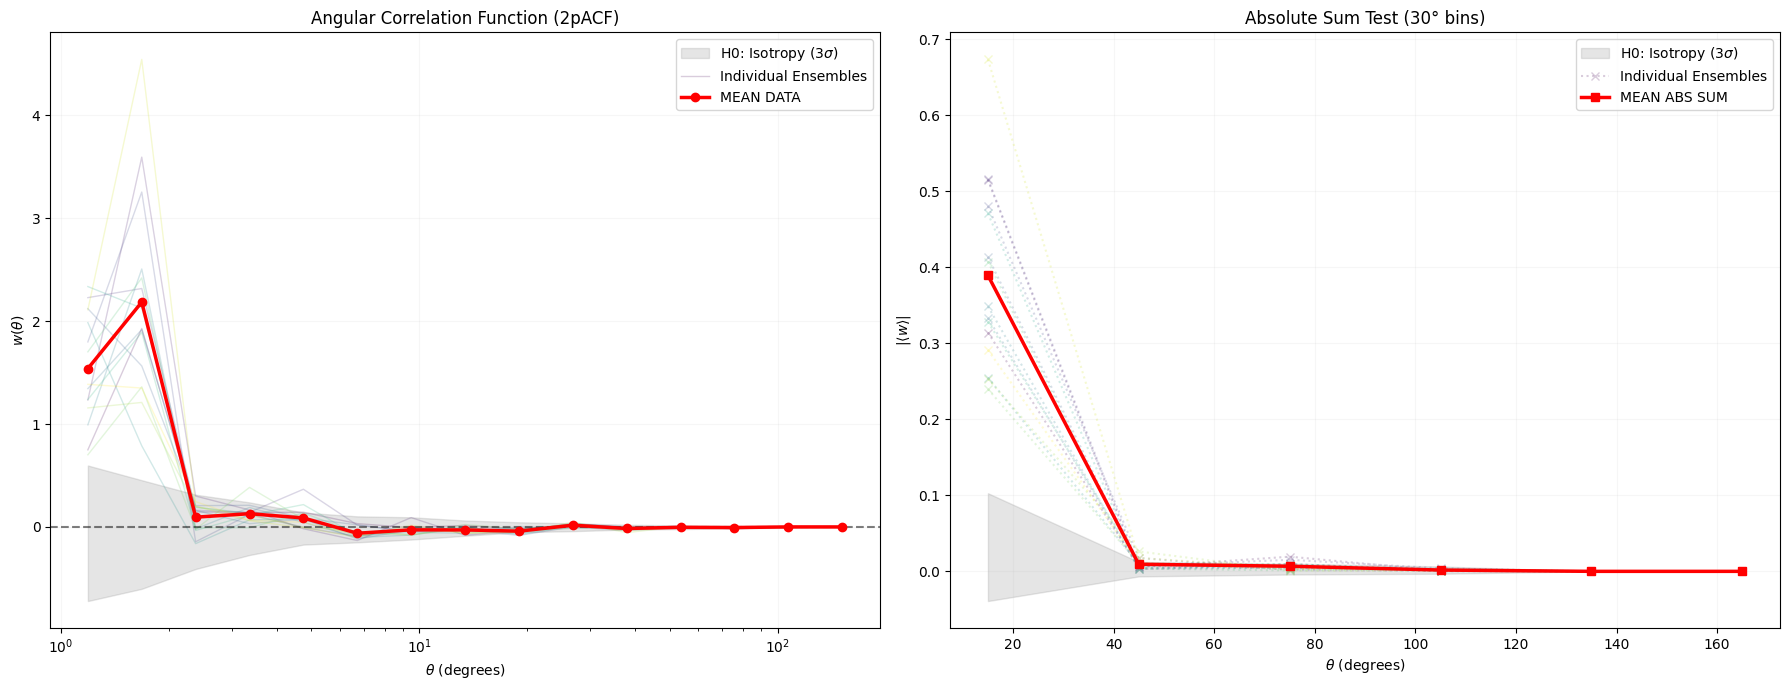

In [6]:
# ==============================================================
# Plotting
# ==============================================================

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
colors = plt.cm.viridis(np.linspace(0, 1, 15))

# --- 2pACF ---
ax[0].fill_between(theta,
                   h0_median - 3*h0_std,
                   h0_median + 3*h0_std,
                   color='gray', alpha=0.2,
                   label=r'H0: Isotropy ($3\sigma$)')

for i in range(15):
    lbl = "Individual Ensembles" if i == 0 else ""
    ax[0].plot(theta, all_w_obs[i],
               color=colors[i], alpha=0.2, lw=1, label=lbl)

ax[0].plot(theta, mean_w,
           color='red', marker='o', lw=2.5,
           label='MEAN DATA', zorder=10)

ax[0].axhline(0, color='black', ls='--', alpha=0.5)
ax[0].set_xscale('log')
ax[0].set_xlabel(r'$\theta$ (degrees)')
ax[0].set_ylabel(r'$w(\theta)$')
ax[0].set_title('Angular Correlation Function (2pACF)')
ax[0].legend()
ax[0].grid(True, alpha=0.1)

# --- Absolute Sum ---
ax[1].fill_between(COARSE_CENTERS,
                   abs_h0_median - 3*abs_h0_std,
                   abs_h0_median + 3*abs_h0_std,
                   color='gray', alpha=0.2,
                   label=r'H0: Isotropy ($3\sigma$)')

for i in range(15):
    lbl = "Individual Ensembles" if i == 0 else ""
    ax[1].plot(COARSE_CENTERS, all_abs_obs[i],
               color=colors[i], alpha=0.2,
               marker='x', ls=':', label=lbl)

ax[1].plot(COARSE_CENTERS, mean_abs,
           color='red', marker='s', lw=2.5,
           label='MEAN ABS SUM', zorder=10)

ax[1].set_xlabel(r'$\theta$ (degrees)')
ax[1].set_ylabel(r'$|\langle w \rangle|$')
ax[1].set_title('Absolute Sum Test (30° bins)')
ax[1].legend()
ax[1].grid(True, alpha=0.1)

plt.tight_layout()
plt.savefig("2pACF_FRB_analysis_15cats_2.png", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# ==============================================================
# Table output
# ==============================================================

df_abs_results = pd.DataFrame(all_abs_obs,
                             columns=[f"{c:.0f} deg" for c in COARSE_CENTERS])

df_abs_results.index = [f"Comb_{i+1}" for i in range(15)]

print("\n--- Absolute Sum Test Table ---")
print(df_abs_results)

print("\nMean Absolute Sum:")
print(df_abs_results.mean())


--- Absolute Sum Test Table ---
           15 deg    45 deg    75 deg   105 deg  135 deg  165 deg
Comb_1   0.314109  0.005742  0.019315  0.000971      0.0      0.0
Comb_2   0.514903  0.002770  0.009664  0.000631      0.0      0.0
Comb_3   0.515767  0.006751  0.015228  0.003971      0.0      0.0
Comb_4   0.480362  0.017638  0.001620  0.000738      0.0      0.0
Comb_5   0.413631  0.006613  0.007392  0.000099      0.0      0.0
Comb_6   0.333235  0.005236  0.004500  0.001426      0.0      0.0
Comb_7   0.348552  0.003167  0.004953  0.003529      0.0      0.0
Comb_8   0.254851  0.009655  0.003319  0.003662      0.0      0.0
Comb_9   0.470866  0.004139  0.009656  0.001750      0.0      0.0
Comb_10  0.328164  0.010235  0.006015  0.001015      0.0      0.0
Comb_11  0.407497  0.003600  0.001247  0.002247      0.0      0.0
Comb_12  0.239719  0.010594  0.009006  0.002364      0.0      0.0
Comb_13  0.253243  0.026162  0.001086  0.000377      0.0      0.0
Comb_14  0.673306  0.017643  0.004561  0.00